# Training a multilayer perceptron from scratch, in JAX

Build an MLP out of nothing but arrays — the parameters, the forward pass, the optimizers, and the training
loop. `jax.grad` gives you backpropagation; write everything else yourself.

The target is a sum of four sine waves of **equal amplitude** at frequencies 1, 2, 4 and 8. 

Acknowledgement: I used ChatGPT (OpenAI) to help explain concepts, debug and improve my code, and suggest implementations and visualizations. I reviewed and modified its suggestions and verified the final code and results myself.

In [1]:
# !pip install -q jax jaxlib matplotlib

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import copy

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.4.38 | devices: [CpuDevice(id=0)]


## The data


In [2]:
FREQS = jnp.array([1.0, 2.0, 4.0, 8.0])
NOISE_STD = 0.02


def target_fn(x):
    """fn(x): (n,) -> (n,)"""
    return jnp.mean(jnp.sin(2 * jnp.pi * FREQS * x[:, None]), axis=-1) # y = (sinπx + sin2πx + sin4πx + sin8πx) / 4. [:, None] turns the 1D array to a 2D column array.


def make_data(key, n=2048, noise_std=NOISE_STD):
    """
    Generate the training dataset.

    n: number of training data points

    Returns:
        X: input data with shape (n, 1)
        Y: output data with shape (n, 1)
    """
    key_x, key_noise = jax.random.split(key)
    x = jax.random.uniform(key_x, (n,), minval=0.0, maxval=1.0)
    y = target_fn(x) + noise_std * jax.random.normal(key_noise, (n,)) # add random noise to generate the training output data
    return x[:, None], y[:, None]


X, Y = make_data(jax.random.key(0))

print(f"target variance : {float(Y.var()):.4f}")   # silly baseline: the error you get by predicting the mean

target variance : 0.1273


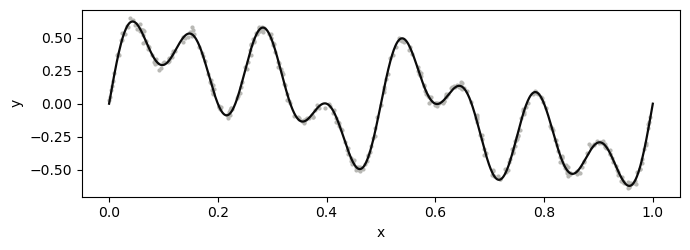

In [3]:
grid = jnp.linspace(0, 1, 1000)
plt.figure(figsize=(7, 2.6))
plt.scatter(np.array(X[:400, 0]), np.array(Y[:400, 0]), s=4, color="#b8b8b4")
plt.plot(np.array(grid), np.array(target_fn(grid)), color="#0b0b0b", lw=1.6)
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

---
## 1. The network

Write three functions:

- `init_mlp(key, layer_sizes)` — the parameters. Think about what a layer actually *is*, and about the scale
  of the initial random draw.
- `forward(params, x)` — `activation` on the hidden layers, nothing on the output.
- `loss_fn(params, x, y)` — mean squared error.

Use `layer_sizes = [1, 128, 128, 1]`. Four layers: input with layer size 1 (1 input), hidden layer one with layer size 128 (128 neurons), hidden layer two with layer size 128 (128 neurons), output with layer size 1 (1 output). There are three transformations between four layers (four sets of neurons).

In [4]:
def init_mlp(key, layer_sizes):
    params = []

    # One independent random key for each layer
    keys = jax.random.split(key, num=len(layer_sizes) - 1)

    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # He initialization (The components of W have normal distribution with variance 2 / n_in). (Named after Kaiming He).
        W = jax.random.normal(keys[i], (n_in, n_out)) * jnp.sqrt(2.0 / n_in)
        b = jnp.zeros(n_out)

        params.append((W, b))

    return params


def forward(params, x):
    # hidden layers
    for W, b in params[:-1]:
        x = activation(x @ W + b) # @ means matrix multiplication

    # output layer -- no activation (the activation is relu, but the ouput needs to be able to take negative values)
    W, b = params[-1]
    return x @ W + b


def loss_fn(params, x, y):
    y_pred = forward(params, x)
    return jnp.mean((y_pred - y) ** 2)


def activation(x):
    return jax.nn.relu(x)

---
## 2. The training loop

Minibatches of 128, reshuffled every epoch, 400 epochs. Get gradients with `jax.grad`. Wrap the step in
`@jax.jit` or it will be slow.

---
## 3. The optimizers

Implement each one from its update equation:

1. **Gradient descent** — full batch, one step per epoch
2. **SGD** — minibatch
3. **SGD with momentum**
4. **Adagrad**
5. **Adam**
6. **Muon** — if you get that far, but it is waaaay trickier so don't get discouraged if you stop at Adam!

Look the update rules up. Muon is recent and not in textbooks:
[kellerjordan.github.io/posts/muon](https://kellerjordan.github.io/posts/muon/).

In [5]:
def zeros_like_params(params):
    return [
        (jnp.zeros_like(W), jnp.zeros_like(b))
        for W, b in params
    ]

    
# initialization
# momentum = zeros_like_params(params)
# accum = zeros_like_params(params)


# In Python programming, snake_case is the official naming convention
# where all letters are written in lowercase,
# and multiple words are separated by an underscore.


# jax.grad() differentiate w.r.t. the zeroth argument of the function by default
# grads = jax.grad(loss_fn)(params, x_batch, y_batch)


# jax.jit enables just-in-time compilation and makes the function runs faster
@jax.jit
def grad_update(params, grads, lr):
    """One gradient-descent/SGD parameter update."""
    return [
        (W - lr * dW, b - lr * db)
        for (W, b), (dW, db) in zip(params, grads)
    ]


@jax.jit
def momentum_update(params, grads, momentum, lr, beta=0.9):
    """SGD with momentum."""
    new_params = []
    new_momentum = []

    for (W, b), (dW, db), (mW, mb) in zip(params, grads, momentum):
        mW = beta * mW + (1 - beta) * dW
        mb = beta * mb + (1 - beta) * db

        W = W - lr * mW
        b = b - lr * mb

        new_params.append((W, b))
        new_momentum.append((mW, mb))

    return new_params, new_momentum


@jax.jit
def adagrad_update(params, grads, accum, lr, eps=1e-8):
    """Adagrad."""
    new_params = []
    new_accum = []

    for (W, b), (dW, db), (sW, sb) in zip(params, grads, accum):
        sW = sW + dW**2
        sb = sb + db**2

        W = W - lr * dW / (jnp.sqrt(sW) + eps)
        b = b - lr * db / (jnp.sqrt(sb) + eps)

        new_params.append((W, b))
        new_accum.append((sW, sb))

    return new_params, new_accum


@jax.jit
def adam_update(
    params, grads, momentum, accum, t, lr,
    beta1=0.9, beta2=0.999, eps=1e-8
):
    """Adam."""
    new_params = []
    new_momentum = []
    new_accum = []

    for (W, b), (dW, db), (mW, mb), (sW, sb) in zip(
        params, grads, momentum, accum
    ):
        # First momentum
        mW = beta1 * mW + (1 - beta1) * dW
        mb = beta1 * mb + (1 - beta1) * db

        # Second momentum (accum)
        sW = beta2 * sW + (1 - beta2) * dW**2
        sb = beta2 * sb + (1 - beta2) * db**2

        # Bias correction (the momenta are biased toward zero in early training because they are initialized to be zero)
        mW_hat = mW / (1 - beta1**t)
        mb_hat = mb / (1 - beta1**t)

        sW_hat = sW / (1 - beta2**t)
        sb_hat = sb / (1 - beta2**t)

        # Parameter update
        W = W - lr * mW_hat / (jnp.sqrt(sW_hat) + eps)
        b = b - lr * mb_hat / (jnp.sqrt(sb_hat) + eps)

        new_params.append((W, b))
        new_momentum.append((mW, mb))
        new_accum.append((sW, sb))

    return new_params, new_momentum, new_accum

---
## 4. What to report

- **All six loss curves on one set of axes**, log scale on y. Plot against both epochs and steps

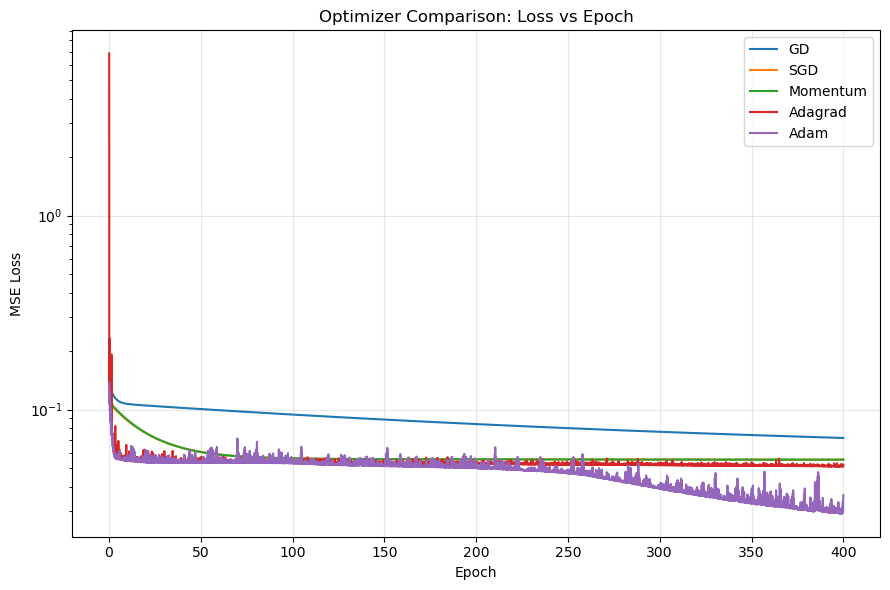

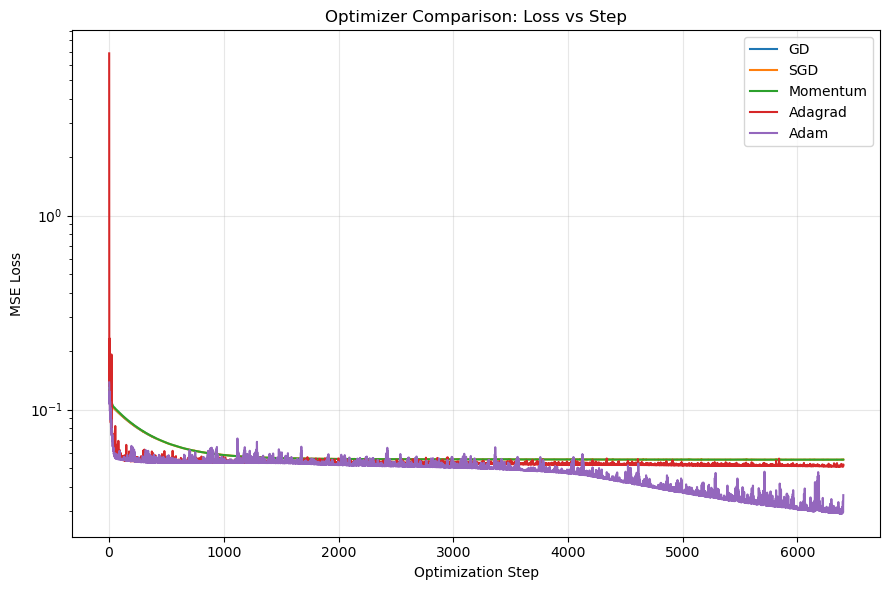

Final losses:
------------------------------
GD        : 7.141083e-02
SGD       : 5.523335e-02
Momentum  : 5.521099e-02
Adagrad   : 5.189310e-02
Adam      : 3.621757e-02


In [6]:
# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

layer_sizes = [1, 128, 128, 1]

n_epochs = 400
batch_size = 128

# You may want to tune these learning rates separately. Note that for Adagrad the effective learning rate is always decreasing.
learning_rates = {
    "GD":       1e-3,
    "SGD":      1e-3,
    "Momentum": 1e-3,
    "Adagrad":  1e-2,
    "Adam":     1e-3,
}


# ------------------------------------------------------------
# Use exactly the same initial network for every optimizer
# ------------------------------------------------------------

init_key = jax.random.key(0)
initial_params = init_mlp(init_key, layer_sizes)


# ------------------------------------------------------------
# Full-batch Gradient Descent
# ------------------------------------------------------------

def train_gd(initial_params, X, Y, n_epochs, lr):

    params = copy.deepcopy(initial_params) # modifying the deep copy does not change the original object

    losses = []
    epochs = []
    steps = []

    step_count = 0

    for epoch in range(n_epochs):

        # Gradient from the entire dataset
        grads = jax.grad(loss_fn)(params, X, Y)

        # Update parameters
        params = grad_update(params, grads, lr)

        step_count += 1

        # Evaluate loss on entire dataset
        loss = loss_fn(params, X, Y)

        losses.append(float(loss))
        epochs.append(epoch + 1)
        steps.append(step_count)

    history = {
        "loss": losses,
        "epoch": epochs,
        "step": steps,
    }

    return params, history


# ------------------------------------------------------------
# Minibatch training:
# SGD, Momentum, Adagrad, Adam
# ------------------------------------------------------------

def train_minibatch(
    optimizer,
    initial_params,
    X,
    Y,
    key,
    n_epochs,
    batch_size,
    lr,
):

    params = copy.deepcopy(initial_params)

    losses = []
    epochs = []
    steps = []

    step_count = 0

    # Optimizer states
    momentum = zeros_like_params(params)
    accum = zeros_like_params(params)

    n_samples = len(X)

    for epoch in range(n_epochs):

        # ----------------------------------------
        # Reshuffle at the beginning of each epoch
        # ----------------------------------------
        key, subkey = jax.random.split(key)

        permutation = jax.random.permutation(
            subkey,
            n_samples
        )

        X_shuffled = X[permutation]
        Y_shuffled = Y[permutation]

        # ----------------------------------------
        # Loop over minibatches
        # ----------------------------------------
        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            Y_batch = Y_shuffled[start:end]

            # Compute gradient on this minibatch
            grads = jax.grad(loss_fn)(
                params,
                X_batch,
                Y_batch
            )

            # ------------------------------------
            # Optimizer-specific update
            # ------------------------------------

            if optimizer == "SGD":

                params = grad_update(
                    params,
                    grads,
                    lr
                )


            elif optimizer == "Momentum":

                params, momentum = momentum_update(
                    params,
                    grads,
                    momentum,
                    lr
                )


            elif optimizer == "Adagrad":

                params, accum = adagrad_update(
                    params,
                    grads,
                    accum,
                    lr
                )


            elif optimizer == "Adam":

                # Adam's t starts at 1
                t = step_count + 1

                params, momentum, accum = adam_update(
                    params,
                    grads,
                    momentum,
                    accum,
                    t,
                    lr
                )


            else:
                raise ValueError(
                    f"Unknown optimizer: {optimizer}"
                )

            step_count += 1

            # ------------------------------------
            # Evaluate on the FULL dataset
            # ------------------------------------
            loss = loss_fn(params, X, Y)

            losses.append(float(loss))

            # Fractional epoch makes the plot smoother
            epoch_position = (
                epoch
                + min(end, n_samples) / n_samples
            )

            epochs.append(epoch_position)
            steps.append(step_count)


    history = {
        "loss": losses,
        "epoch": epochs,
        "step": steps,
    }

    return params, history


# ============================================================
# Train all optimizers
# ============================================================

results = {}
final_params = {}


# ------------------------------------------------------------
# Gradient Descent
# ------------------------------------------------------------

params_gd, history_gd = train_gd(
    initial_params,
    X,
    Y,
    n_epochs,
    learning_rates["GD"]
)

results["GD"] = history_gd
final_params["GD"] = params_gd


# ------------------------------------------------------------
# Minibatch optimizers
# ------------------------------------------------------------

for i, optimizer in enumerate(
    ["SGD", "Momentum", "Adagrad", "Adam"]
):

    # Separate reproducible shuffle key
    # train_key = jax.random.key(i + 1)

    # Same shuffle sequence for a fair comparison
    train_key = jax.random.key(1)

    params, history = train_minibatch(
        optimizer,
        initial_params,
        X,
        Y,
        train_key,
        n_epochs,
        batch_size,
        learning_rates[optimizer]
    )

    results[optimizer] = history
    final_params[optimizer] = params


# ============================================================
# Figure 1: Loss vs Epoch
# ============================================================

plt.figure(figsize=(9, 6))

for name, history in results.items():

    plt.plot(
        history["epoch"],
        history["loss"],
        label=name
    )

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Optimizer Comparison: Loss vs Epoch")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: Loss vs Optimization Step
# ============================================================

plt.figure(figsize=(9, 6))

for name, history in results.items():

    plt.plot(
        history["step"],
        history["loss"],
        label=name
    )

plt.yscale("log")

plt.xlabel("Optimization Step")
plt.ylabel("MSE Loss")
plt.title("Optimizer Comparison: Loss vs Step")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# Print final losses
# ============================================================

print("Final losses:")
print("-" * 30)

for name, history in results.items():
    print(
        f"{name:10s}: {history['loss'][-1]:.6e}"
    )

---
## 5. One more plot

Now make a plot I did not ask for.



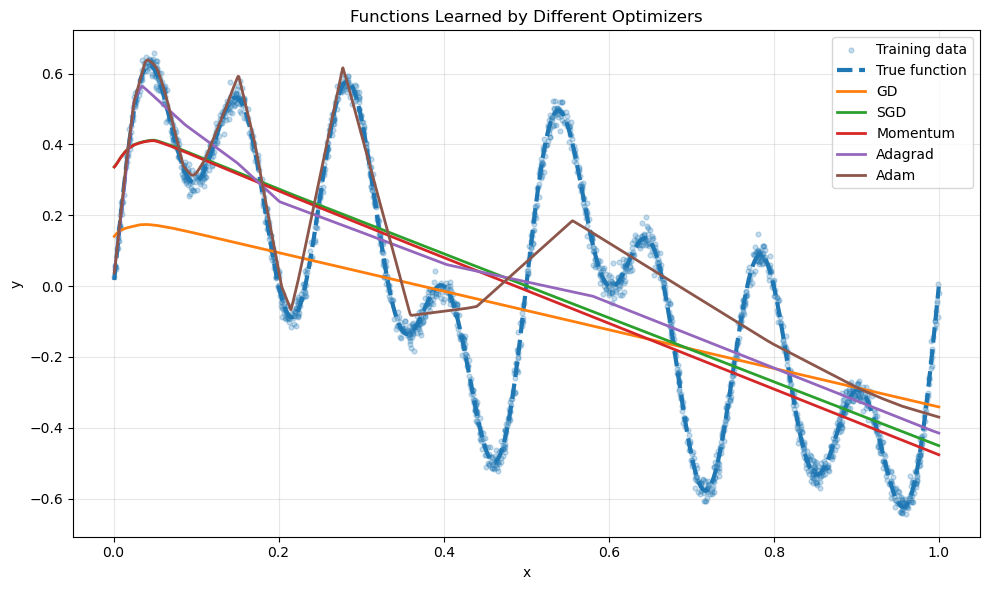

In [7]:
# ============================================================
# Compare the functions learned by each optimizer
# ============================================================

# Dense x grid for smooth curves
x_plot = jnp.linspace(
    float(X.min()),
    float(X.max()),
    1000
)[:, None]

plt.figure(figsize=(10, 6))

# Original noisy training data
plt.scatter(
    X[:, 0],
    Y[:, 0],
    s=12,
    alpha=0.25,
    label="Training data"
)

# True underlying function
y_true = target_fn(x_plot[:, 0])

plt.plot(
    x_plot[:, 0],
    y_true,
    linewidth=3,
    linestyle="--",
    label="True function"
)

# Predictions from each optimizer
for name, params in final_params.items():

    y_pred = forward(params, x_plot)

    plt.plot(
        x_plot[:, 0],
        y_pred[:, 0],
        linewidth=2,
        label=name
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Functions Learned by Different Optimizers")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()